<a href="https://colab.research.google.com/github/nlan082/bai_tap_AI/blob/main/tieuduong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-fuzzy

In [78]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [79]:
#
sugar=ctrl.Antecedent(np.arange(60, 210, 1), 'sugar')
bmi=ctrl.Antecedent(np.arange(10, 35, 0.1), 'bmi')
urination=ctrl.Antecedent(np.arange(0, 3, 1), 'urination')
fatigue=ctrl.Antecedent(np.arange(0, 3, 1), 'fatigue')
risk=ctrl.Consequent(np.arange(0, 4, 1), 'risk')
#
sugar['low']=fuzz.trimf(sugar.universe, [60, 60, 80])
sugar['normal']=fuzz.trimf(sugar.universe, [80, 100, 120])
sugar['high']=fuzz.trimf(sugar.universe, [120, 160, 200])
sugar['veryhigh']=fuzz.trimf(sugar.universe, [200, 210, 210])
bmi['u']=fuzz.trimf(bmi.universe, [10, 18.5, 18.5])
bmi['n']=fuzz.trimf(bmi.universe, [18.5, 21.7, 24.9])
bmi['o']=fuzz.trimf(bmi.universe, [25, 30, 30])
bmi['ob']=fuzz.trimf(bmi.universe, [30, 35, 35])
urination['r']=fuzz.trimf(urination.universe, [0, 0, 1])
urination['s']=fuzz.trimf(urination.universe, [0, 1, 2])
urination['o']=fuzz.trimf(urination.universe, [1, 2, 3])
fatigue['l']=fuzz.trimf(fatigue.universe, [0, 0, 1])
fatigue['m']=fuzz.trimf(fatigue.universe, [0, 1, 2])
fatigue['h']=fuzz.trimf(fatigue.universe, [1, 2, 3])
risk['lr']=fuzz.trimf(risk.universe, [0, 0, 1])
risk['mr']=fuzz.trimf(risk.universe, [0, 1, 2])
risk['hr']=fuzz.trimf(risk.universe, [1, 2, 3])
risk['vhr']=fuzz.trimf(risk.universe, [2, 3, 3])


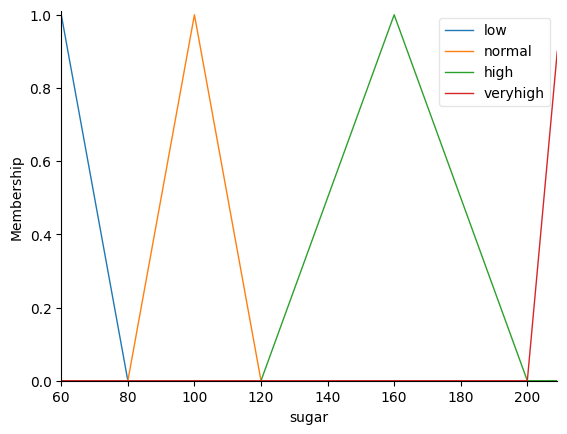

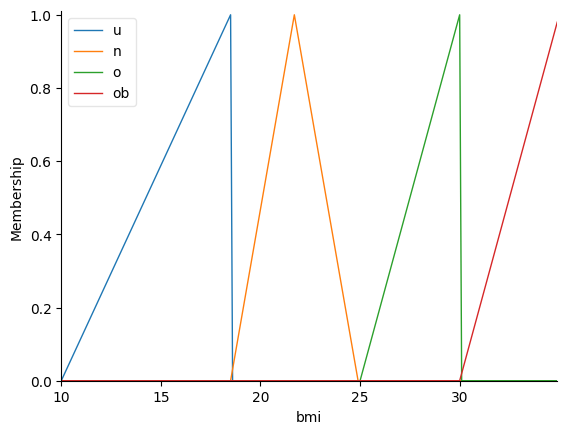

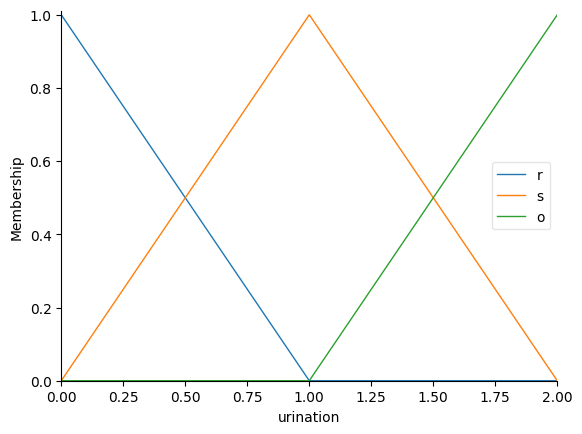

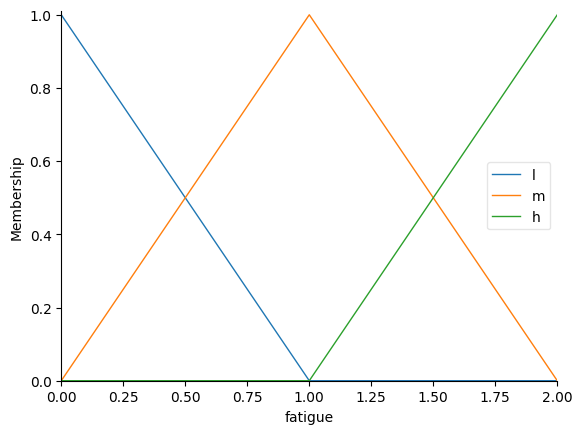

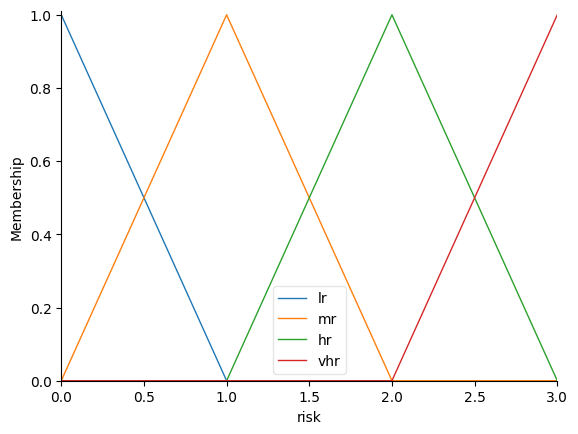

In [80]:
sugar.view()
bmi.view()
urination.view()
fatigue.view()
risk.view()

In [81]:
#
rule1=ctrl.Rule(sugar['veryhigh']&urination['o'], risk['vhr'])
rule2=ctrl.Rule(sugar['veryhigh']&urination['s'], risk['hr'])
rule3=ctrl.Rule(sugar['high']&urination['o'], risk['hr'])
rule4=ctrl.Rule(sugar['normal']&urination['r'], risk['lr'])
#
rule5=ctrl.Rule(sugar['veryhigh']&bmi['ob'], risk['vhr'])
rule6=ctrl.Rule(sugar['veryhigh']&bmi['o'], risk['hr'])
rule7=ctrl.Rule(sugar['high']&bmi['o'], risk['hr'])
rule8=ctrl.Rule(sugar['high']&bmi['o'], risk['mr'])
rule9=ctrl.Rule(sugar['normal']&bmi['o'], risk['lr'])
#
rule10=ctrl.Rule(sugar['veryhigh']&fatigue['h'], risk['vhr'])
rule11=ctrl.Rule(sugar['high']&fatigue['h'], risk['hr'])
rule12=ctrl.Rule(sugar['high']&fatigue['m'], risk['mr'])
rule13=ctrl.Rule(sugar['normal']&fatigue['l'], risk['lr'])


Mức độ rủi ro: 0.49999999999999734


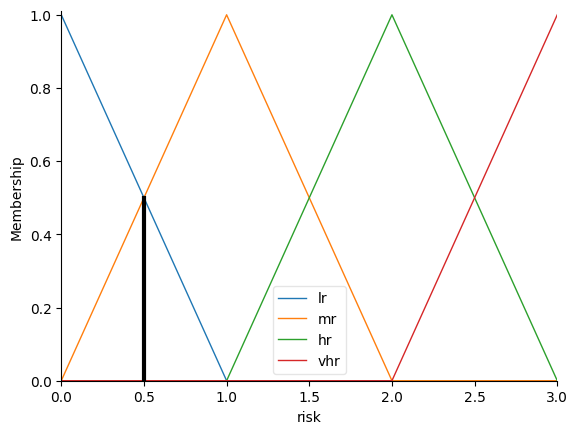

In [83]:
#
risk1 = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12, rule13])  # Thêm tất cả các rule vào đây
risk2 = ctrl.ControlSystemSimulation(risk1)
#
risk2.input['sugar'] = 100
risk2.input['bmi'] = 25
risk2.input['urination'] = 2
risk2.input['fatigue'] = 2
risk2.compute()
print("Mức độ rủi ro:", risk2.output['risk'])
risk.view(sim=risk2)
